## Importações

In [729]:
# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Bibliotecas de EDA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Carregando nosso dataframe

In [730]:
df = pd.read_csv(r"data\loan_dataset.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Colunas

- **Loan_ID** - Identificador único da solicitação
- **Gender** - Gênero do solicitante
- **Married** - Estado civil do solicitante
- **Dependents** - Número de pessoas que dependem financeiramente do solicitante
- **Education** - Nível de escolaridade
- **Self_Employed** - Se o solicitante é autônomo ou empresário
- **ApplicantIncome** - Renda mensal do solicitante
- **CoapplicantIncome** - Renda mensal do co-solicitante
- **LoanAmount** - Valor do empréstimo solicitado
- **Loan_Amount_Term** - Prazo do empréstimo em meses
- **Credit_History** - Se o solicitante tem histórico de crédito limpo (feature mais importante)
- **Property_Area** - Área onde o imóvel está localizado
- **Loan_Status** - Se o empréstimo foi aprovado ou não **(target)** 

## Visualização do nosso dataset

In [ ]:

print("======= Informações básicas sobre o nosso dataset =======")
print(df.info())
print(df.describe())

print(f"\nNúmero de Linhas e Colunas: {df.shape}")

======= INFORMAÇÕES BÁSICAS SOBRE O NOSSO DATASET =======
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB
None
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amou

In [732]:
print("==== Quantidade de valores nulos ====")
print(df.isnull().sum())

==== Quantidade de valores nulos ====
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [733]:
# Verificando os valores existentes nas colunas categóricas
colunas_categoricas = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for coluna in colunas_categoricas:
    print(f'\nValores na coluna {coluna}: {df[coluna].unique()}')


Valores na coluna Gender: <StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

Valores na coluna Married: <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

Valores na coluna Dependents: <StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

Valores na coluna Education: <StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

Valores na coluna Self_Employed: <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

Valores na coluna Property_Area: <StringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str

Valores na coluna Loan_Status: <StringArray>
['Y', 'N']
Length: 2, dtype: str


In [734]:
# Verificando a frequência em que cada valor aparece nessas colunas categóricas
for coluna in colunas_categoricas:
  print(f"\n==== Frequência dos valores da coluna: {coluna} ====")
  print(df[coluna].value_counts())


==== Frequência dos valores da coluna: Gender ====
Gender
Male      489
Female    112
Name: count, dtype: int64

==== Frequência dos valores da coluna: Married ====
Married
Yes    398
No     213
Name: count, dtype: int64

==== Frequência dos valores da coluna: Dependents ====
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

==== Frequência dos valores da coluna: Education ====
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

==== Frequência dos valores da coluna: Self_Employed ====
Self_Employed
No     500
Yes     82
Name: count, dtype: int64

==== Frequência dos valores da coluna: Property_Area ====
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

==== Frequência dos valores da coluna: Loan_Status ====
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [735]:
# Tipo dos dados das colunas do dataframe
print(f"Tipos das colunas: {df.dtypes.unique()}")

Tipos das colunas: [<StringDtype(storage='python', na_value=nan)> dtype('int64')
 dtype('float64')]


# Análise estatística

In [736]:
# Identificar as colunas numéricas
df.info()

colunas_numericas = ['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


O boxplot foi aplicado para verificar a quantidade de outliers em algumas colunas numéricas

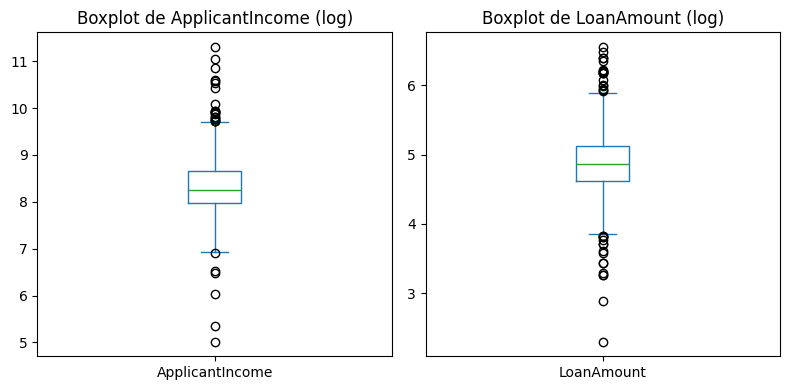

In [737]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

# A aplicação logarítmica é utilizada quando os valores numéricos de uma coluna são muito distantes, o que geram muitos outliers
# Para diminuir um pouco isso o log transforma eles numa distribuição mais próxima

# Boxplot de ApplicantIncome
df['ApplicantIncome'].apply(np.log1p).plot(kind='box', ax=ax[0])
ax[0].set_title('Boxplot de ApplicantIncome (log)')

# Boxplot de LoanAmount
df['LoanAmount'].apply(np.log1p).plot(kind='box', ax=ax[1])
ax[1].set_title('Boxplot de LoanAmount (log)')

plt.tight_layout()
plt.show()

# Limpeza dos dados

## Verificações

In [738]:
print("==== Quantidade de valores ausentes ====")
print(df.isnull().sum())

print("\n==== Verificação de tipos incorretos nas colunas ====")
print(df.info())

==== Quantidade de valores ausentes ====
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

==== Verificação de tipos incorretos nas colunas ====
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   

## Tratamento

O preenchimento proporcional aleatório é uma técnica utilizada para preencher valores nulos em colunas em que um valor é muito dominante nela

In [739]:
# Coluna 'Gender'
proporcao = df['Gender'].value_counts(normalize=True) # calculando a proporção original

# Preenche os nulos respeitando a proporção
nulos = df['Gender'].isnull().sum()
valores_aleatorios = np.random.choice(proporcao.index, size=nulos, p=proporcao.values)

df.loc[df['Gender'].isnull(), 'Gender'] = valores_aleatorios

In [740]:
# Checando se o preenchimento funcionou
df['Gender'].value_counts(normalize=True)  
df['Gender'].isnull().sum() # se funcionou, será printado '0'

np.int64(0)

In [741]:
# Coluna 'Married'
proporcao = df['Married'].value_counts(normalize=True) # calculando a proporção original

# Preenche os nulos respeitando a proporção
nulos = df['Married'].isnull().sum()
valores_aleatorios = np.random.choice(proporcao.index, size=nulos, p=proporcao.values)

df.loc[df['Married'].isnull(), 'Married'] = valores_aleatorios

In [742]:
# Checando se o preenchimento funcionou
df['Married'].value_counts(normalize=True)  
df['Married'].isnull().sum() # se funcionou, será printado '0'

np.int64(0)

In [743]:
# Convertendo o valor '3+' da coluna 'Dependents' em float apenas com o número 3
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(float)

In [744]:
# Pelo fato do valor dessa coluna ter que ser sempre um número inteiro, é mais adequado preencher os valores nulos dela com a mediana
# A distribuição dos valores é assimétrica, e o fato da mediana não ser afetada pela quantidade discrepante de valores mínimos e máximos ela se torna mais confiável
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].median())

In [745]:
# Checando se o preenchimento funcionou
df['Dependents'].value_counts(normalize=True)  
df['Dependents'].isnull().sum() # se funcionou, será printado '0'

np.int64(0)

In [746]:
# Coluna 'Self_Employed'
proporcao = df['Self_Employed'].value_counts(normalize=True) # calculando a proporção original

# Preenche os nulos respeitando a proporção
nulos = df['Self_Employed'].isnull().sum()
valores_aleatorios = np.random.choice(proporcao.index, size=nulos, p=proporcao.values)

df.loc[df['Self_Employed'].isnull(), 'Self_Employed'] = valores_aleatorios

In [747]:
# Checando se o preenchimento funcionou
df['Self_Employed'].value_counts(normalize=True)  
df['Self_Employed'].isnull().sum() # se funcionou, será printado '0'

np.int64(0)

In [748]:
# Através do boxplot foi possível perceber a quantidade de outliers presente na coluna 'LoanAmount'
# Devido a assimetria de valores na coluna, o melhor valor a ser utilizado para preencher valores nulos é a mediana
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [749]:
# Checando se o preenchimento funcionou
df['LoanAmount'].value_counts(normalize=True)  
df['LoanAmount'].isnull().sum() # se funcionou, será printado '0'

np.int64(0)

In [750]:
df['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [751]:
# Pelo fato do 360.0 ser um valor muito dominante na coluna, torna-se justificável utilizar a moda para preencher os valores nulos
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

In [752]:
# Checando se o preenchimento funcionou
df['Loan_Amount_Term'].value_counts(normalize=True)  
df['Loan_Amount_Term'].isnull().sum() # se funcionou, será printado '0'

np.int64(0)

In [753]:
# Checando a frequência da coluna 'Credit_History'
df['Credit_History'].value_counts()

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

In [754]:
# Coluna 'Credit_History'
proporcao = df['Credit_History'].value_counts(normalize=True) # calculando a proporção original

# Preenche os nulos respeitando a proporção
nulos = df['Credit_History'].isnull().sum()
valores_aleatorios = np.random.choice(proporcao.index, size=nulos, p=proporcao.values)

df.loc[df['Credit_History'].isnull(), 'Credit_History'] = valores_aleatorios

In [755]:
# Checando se o preenchimento funcionou
df['Credit_History'].value_counts(normalize=True)  
df['Credit_History'].isnull().sum() # se funcionou, será printado '0'

np.int64(0)

In [756]:
# Transformando as colunas que estavam como float para int. Visto que todas possuem apenas o 0 na casa decimal
df[colunas_numericas] = df[colunas_numericas].astype(int)

# Feature Engineering e dados categóricos

## Verificação

In [757]:
# Verificando os valores das nossas colunas categóricas
colunas_categoricas = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status'] # lista com todas as colunas categóricas do dataframe
for coluna in colunas_categoricas:
    print(f'\nValores na coluna {coluna}: {df[coluna].unique()}')


Valores na coluna Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str

Valores na coluna Married: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Valores na coluna Education: <StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

Valores na coluna Self_Employed: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Valores na coluna Property_Area: <StringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str

Valores na coluna Loan_Status: <StringArray>
['Y', 'N']
Length: 2, dtype: str


## Transformando os dados categóricos em flags binárias

### A transformação de dados categóricos em flags binárias se dá pelo fato de um modelo não conseguir entender palavras, traduzindo assim para linguagem binária e ele possa entender

### O One-Hot-Encoding é utilizado em colunas categóricas que possuem mais de um valor possível. Assim são criadas uma nova coluna binária para cada categoria

In [758]:
# Transformando nossos dados categóricos em flag binária

# coluna 'Gender'
# Female = 1, Male = 0
df['Gender'] = df['Gender'].replace({'Female': 1, 'Male': 0})


# coluna 'Married'
# Yes = 1, No = 0
df['Married'] = df['Married'].replace({'Yes': 1, 'No': 0})


# coluna 'Education'
# Graduate = 1, Not Graduate = 0
df['Education'] = df['Education'].replace({'Graduate': 1, 'Not Graduate': 0})


# coluna 'Self_Employed'
# Yes = 1, No = 0
df['Self_Employed'] = df['Self_Employed'].replace({'Yes': 1, 'No': 0})


# coluna 'Loan_Status'
# Y = 1, N = 0 
df['Loan_Status'] = df['Loan_Status'].replace({'Y': 1, 'N': 0})


# coluna 'Property_Area'
# foi utilizada a técnica de One-Hot-Encoding
df = pd.get_dummies(df, columns=['Property_Area'], dtype=int)


df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,0,0,0,1,0,5849,0,128,360,1,1,0,0,1
1,LP001003,0,1,1,1,0,4583,1508,128,360,1,0,1,0,0
2,LP001005,0,1,0,1,1,3000,0,66,360,1,1,0,0,1
3,LP001006,0,1,0,0,0,2583,2358,120,360,1,1,0,0,1
4,LP001008,0,0,0,1,0,6000,0,141,360,1,1,0,0,1


## Definindo as nossas features

In [759]:
# Decidir quais features manter, quais descartar
# A feature 'Loan_ID' foi descartada pelo fato de ser só um identificador e não ter valor preditivo
# A feature 'Gender' foi descartada pelo fato de ser eticamente questionável usar o gênero como fator de decisão para aprovar um empréstimo ou não
df = df.drop(columns=['Loan_ID', 'Gender'])

In [760]:
# Colocando a variável dependente na última posição do dataset
features = [col for col in df.columns if col != 'Loan_Status']
features_target = features + ['Loan_Status']
df = df[features_target]

# Definindo as nossas features (X) e o target (y)
X = df.iloc[:, :-1] # todas as colunas menos a última
y = df.iloc[:, -1] # última coluna

df.head()

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Status
0,0,0,1,0,5849,0,128,360,1,0,0,1,1
1,1,1,1,0,4583,1508,128,360,1,1,0,0,0
2,1,0,1,1,3000,0,66,360,1,0,0,1,1
3,1,0,0,0,2583,2358,120,360,1,0,0,1,1
4,0,0,1,0,6000,0,141,360,1,0,0,1,1


In [761]:
# Checando as correlações
df.corr()

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Status
Married,1.000000,0.334216,-0.012304,0.008221,0.051708,0.075947,0.146546,-0.100912,0.022048,-0.006805,0.005845,0.000546,0.091478
Dependents,0.334216,1.000000,-0.055752,0.046473,0.118202,0.030429,0.163103,-0.103864,-0.038966,-0.000816,0.001924,-0.001198,0.010118
Education,-0.012304,-0.055752,1.000000,0.020095,0.140760,0.062290,0.168759,0.073928,0.073846,-0.077520,0.039410,0.034279,0.085884
Self_Employed,0.008221,0.046473,0.020095,1.000000,0.120548,-0.019968,0.110023,-0.027941,-0.031056,0.019912,0.013199,-0.032892,-0.011211
ApplicantIncome,0.051708,0.118202,0.140760,0.120548,1.000000,-0.116604,0.565181,-0.046531,-0.011467,0.015829,-0.014246,-0.000598,-0.004710
CoapplicantIncome,0.075947,0.030429,0.062290,-0.019968,-0.116604,1.000000,0.189218,-0.059382,0.026449,0.005330,-0.027043,0.022775,-0.059188
LoanAmount,0.146546,0.163103,0.168759,0.110023,0.565181,0.189218,1.000000,0.036960,-0.001754,0.043467,-0.005804,-0.036050,-0.033214
Loan_Amount_Term,-0.100912,-0.103864,0.073928,-0.027941,-0.046531,-0.059382,0.036960,1.000000,0.004842,0.034321,0.059141,-0.094279,-0.022549
Credit_History,0.022048,-0.038966,0.073846,-0.031056,-0.011467,0.026449,-0.001754,0.004842,1.000000,-0.007089,0.025853,-0.019844,0.526577
Property_Area_Rural,-0.006805,-0.000816,-0.077520,0.019912,0.015829,0.005330,0.043467,0.034321,-0.007089,1.000000,-0.501646,-0.449168,-0.100694


## Plotagem de gráficos necessários para entender nossos dados antes de treinar nosso modelo

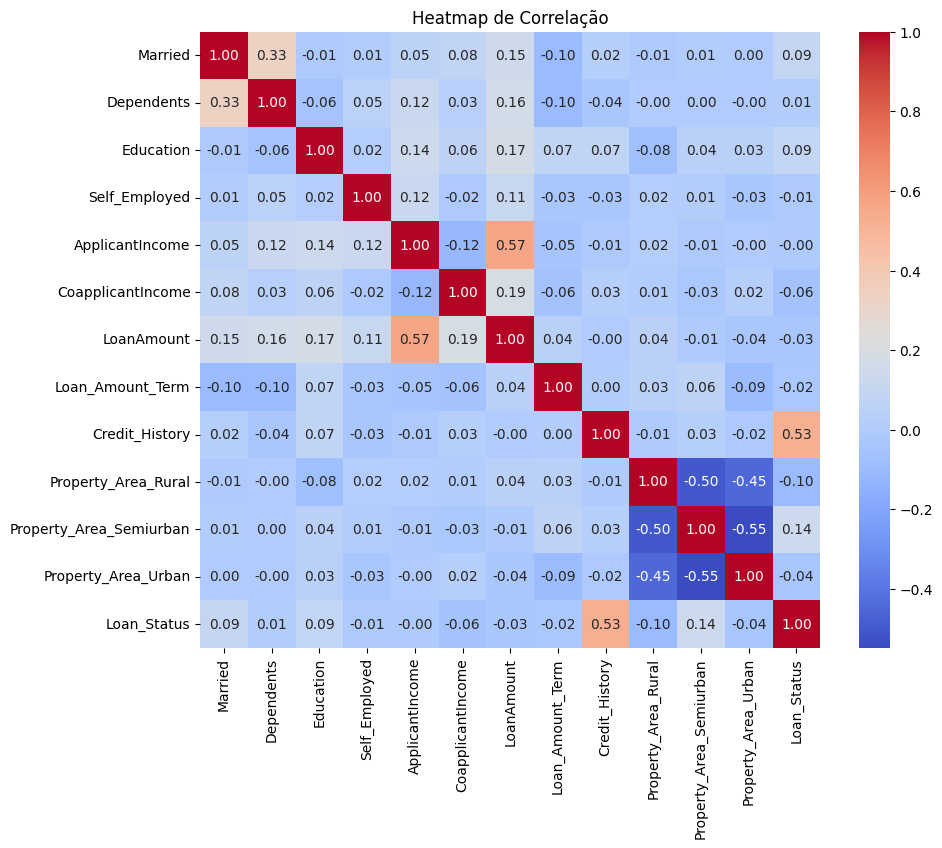

In [762]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap de Correlação')
plt.show()

## Conclusões tiradas com o heatmap:

- 'Credit_History' é a feature mais correlacionada com o target (Loan_Status)
- Imóveis em área semiurbana não possuem muita tendência a serem aprovados
- 'Married' e 'Education' possuem uma correlação fraca

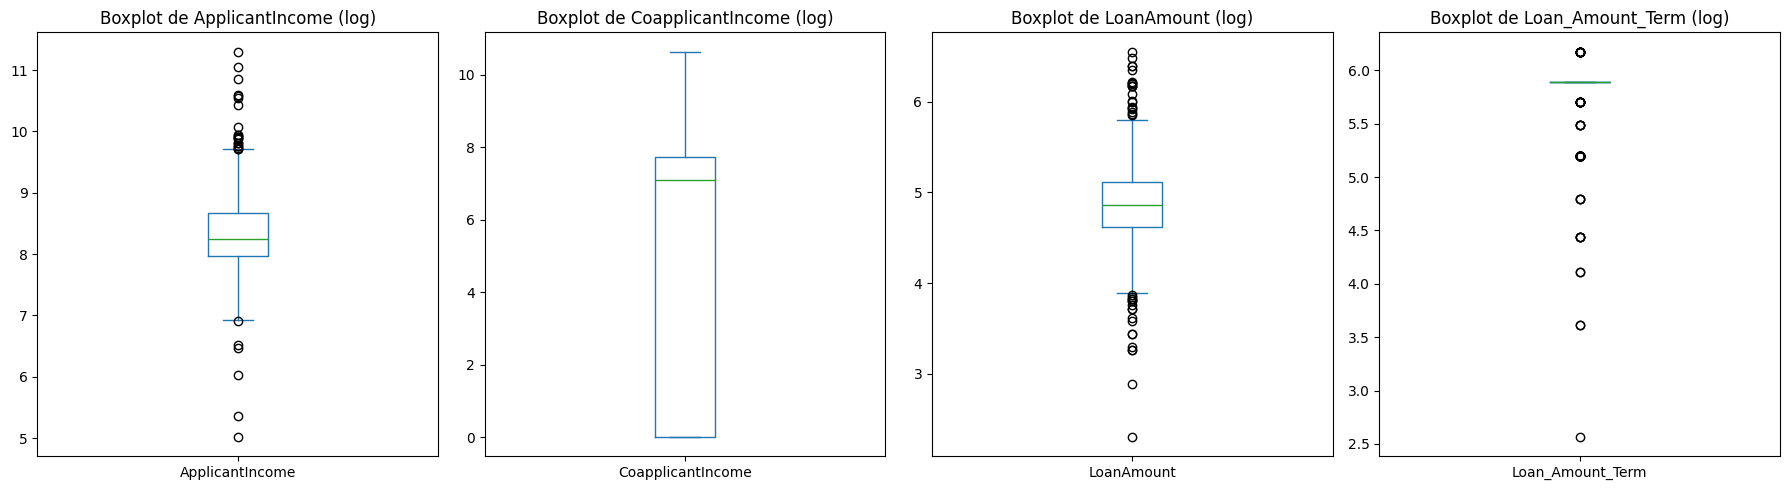

In [763]:
colunas_numericas2 = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(1, len(colunas_numericas2), figsize=(18, 5))

for i, col in enumerate(colunas_numericas2):
    df[col].apply(np.log1p).plot(kind='box', ax=axes[i])
    axes[i].set_title(f'Boxplot de {col} (log)')

plt.tight_layout()
plt.show()

## Conclusões tiradas com os boxplots

- O 'ApplicantIncome' tem uma distribuição até que simétrica após o log e possui muitos solicitantes com renda muito acima da média
- No 'CoapplicantIncome' muitos solicitantes não tem co-solicitante e o tamanho da caixa indica uma alta variabilidade entre quem tem co-solicitante
- No 'LoanAmount' a distribuição fica mais simétrica após o log e possui poucos outliers extremos, ou seja, grande parte dos empréstimos se concentra numa faixa razoável
- No 'Loan_Amount_Term' o fato da caixa ser uma linha confirma que praticamente todos os valores são 360 e os outliers abaixo representam poucos casos com prazos menores

In [764]:
# A coluna não tava sendo reconhecida como int, e sim string
y = y.astype(int)

In [765]:
# Separar os conjuntos de treino e teste
# 80% treino e 20% teste
# número mágico 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

O Feature Scaling é utilizado para colocar todas as features na mesma escala 

Com o Feature Scaling o modelo consegue comparar duas features de forma justa

In [766]:
# Fazer o Feature Scaling (se necessário)
scaler = StandardScaler() # criando o objeto do scaler
X_train_scaled = scaler.fit_transform(X_train) # com a função 'fit_transform' o scaler aprende a média e o desvio padrão de cada coluna olhando pro X_train (fit) e aplica a transformação no X_train usando os valores que acabou de aprender (transform)
X_test_scaled = scaler.transform(X_test) # aplica o 'transform' sem o 'fit'
print("Features standardized")

Features standardized


In [767]:
# Criando o modelo (usando uma classe do sklearn)
# Nesse exemplo é Regressão Logística
model = LogisticRegression(random_state=42)

In [768]:
# Treinar o modelo
# Ele vai calcular o erro, o gradiente, e atualizar os pesos
# Isso vai criar o modelo, e ele vai ser capaz de fazer previsões (criando a função de inferência)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [769]:
# Fazer o teste e as previsões necessárias
y_pred = model.predict(X_test_scaled) # faz as previsões do modelo para cada conjutno de teste
y_pred_proba = model.predict_proba(X_test_scaled) # retorna a probabilidade de cada classe

In [ ]:
# Fazer a avaliação do modelo
accuracy = accuracy_score(y_test, y_pred) # acurácia do modelo
print(f"Accuracy: {accuracy:.4f}") 
print(classification_report(y_test, y_pred)) # relatório mais detalhado sobre as métricas do nosso modelo
print(confusion_matrix(y_test, y_pred)) # matriz de confusão


Accuracy: 0.8618
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123

[[22 16]
 [ 1 84]]


## Explicando melhor sobre as métricas de avaliação

- Precision - dos que modelo disse que foi aprovado, quantos realmente foram? (evita falsos positivos)
- Recall - dos que realmente foram aprovados, quantos o modelo pegou? (evita falsos negativos)
- F1-Score - média entre precision e recall

In [771]:
print(f"\n=== CONCLUSÃO DA ANÁLISE ===")
if accuracy > 0.95:
    print("Excelente: Modelo demonstra performance excepcional.")
elif accuracy > 0.90:
    print("Muito bom: Modelo apresenta alta acurácia.")
elif accuracy > 0.85:
    print("Bom : Modelo apresenta boa performance.")
else:
    print("Melhorias necessárias: Modelo precisa de ajustes.")


=== CONCLUSÃO DA ANÁLISE ===
Bom : Modelo apresenta boa performance.
